Connexion avec Ollama 

In [1]:
import base64
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from PIL import Image

OLLAMA_URL = "http://localhost:11434"
MODEL_NAME = "llava"
TIMEOUT = 240

print("Vérification de la connexion à Ollama...")
print(f"URL : {OLLAMA_URL}")

try:
    resp = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
    if resp.status_code == 200:
        models_data = resp.json()
        models_list = [m['name'] for m in models_data.get('models', [])]
        print("\nOllama connecté !")
        print(f" Modèles disponibles : {models_list}")
        if MODEL_NAME in models_list or any(MODEL_NAME in m for m in models_list):
            print(f"Modèle '{MODEL_NAME}' disponible")
        else:
            print(f"Modèle '{MODEL_NAME}' non trouvé")
            print(f" Lancer : docker exec ollama ollama pull {MODEL_NAME}")
    else:
        print(f"\nErreur HTTP {resp.status_code}")
except requests.exceptions.ConnectionError:
    print("\nImpossible de se connecter à Ollama !")
    print("Vérifiez que Docker tourne et que le container Ollama est démarré :")
    print("> docker start ollama")
    print("> docker ps   (vérifier que 'ollama' apparaît)")
except requests.exceptions.Timeout:
    print("\nTimeout — le serveur ne répond pas")
    print(" Essayez : docker logs ollama")

Vérification de la connexion à Ollama...
URL : http://localhost:11434

Ollama connecté !
 Modèles disponibles : ['llava:latest']
Modèle 'llava' disponible


Verifie si les images existe dans le path

In [2]:
IMAGE_FOLDER = Path("test_images")

IMAGE_FOLDER.mkdir(exist_ok=True)

images = list(IMAGE_FOLDER.glob("*"))

if len(images) == 0:
    print("Aucune image chargé trouvé test_images/")
else:
    print(f"{len(images)} images trouvée")
    for img in images:
        print("-", img)

7 images trouvée
- test_images\brocoli.png
- test_images\burger.png
- test_images\chat.png
- test_images\fraise.png
- test_images\fruit de passion.png
- test_images\glace.png
- test_images\pates.png


Prend l'image et l'upload

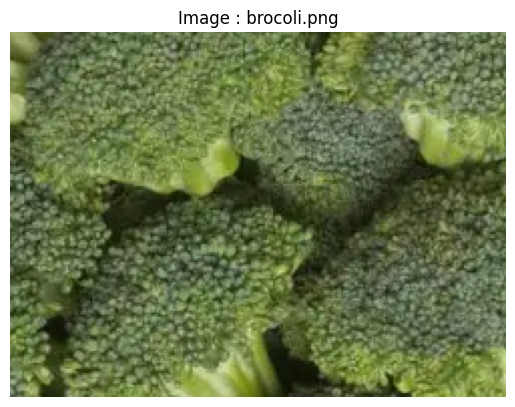

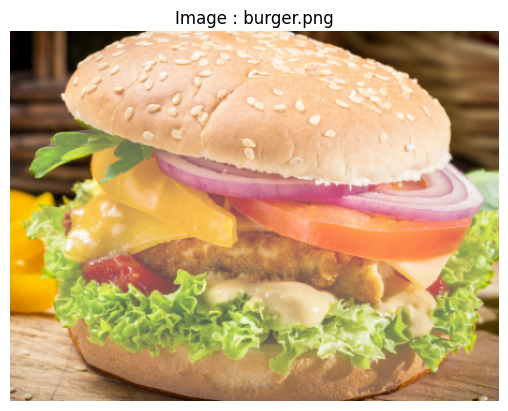

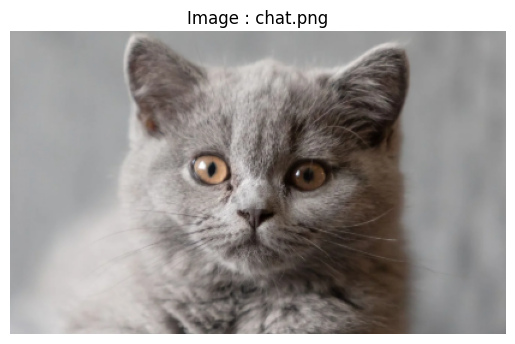

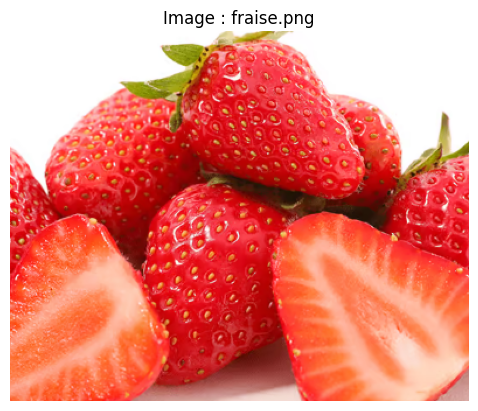

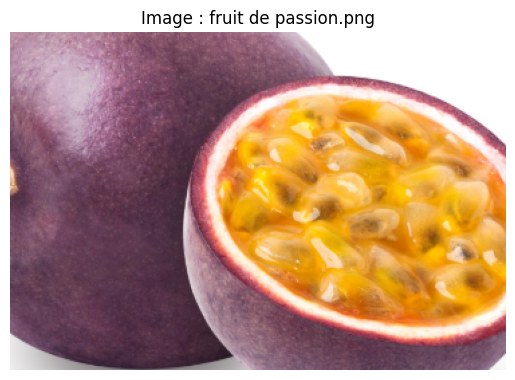

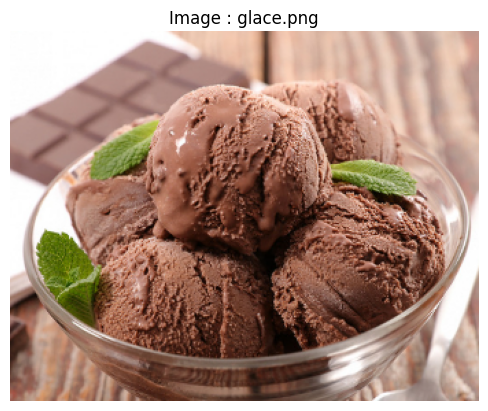

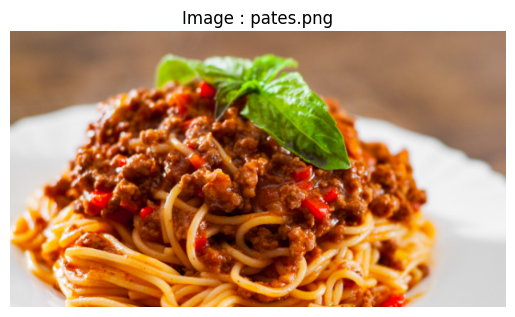

In [3]:
for img_path in images:
    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(f"Image : {img_path.name}")
    plt.axis("off")
    plt.show()

Convertit l'image en base64

In [4]:
def image_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

Pointe vers l'url Ollama afin d'analyser l'image et le prompt qu'on lui fourni + message d'erreur en cas d'erreur API

In [5]:
def analyze_meal(image_base64):
    url = "http://localhost:11434/api/generate"

    prompt = """You are a nutrition expert analyzing a food photo. Respond with ONLY valid JSON, no markdown, no text outside JSON.

    ANALYSIS APPROACH (follow in order):
    1. First, identify if the image shows ONE single food item or MULTIPLE distinct items/dishes.
    2. For a SINGLE item (e.g. one fruit, one piece of food): name that SPECIFIC item precisely
       (e.g. "passion fruit", not "fruit salad" — a single cut fruit is NOT a salad).
    3. For MULTIPLE items: only then consider naming it as a "salad", "platter", "mixed dish", etc.
    4. Pay attention to: skin/peel texture, seed pattern, color gradient, and shape —
       these distinguish similar-looking foods (e.g. passion fruit pulp has fibrous seeds
       inside a hard shell, unlike a cut fruit salad which shows multiple separate fruit pieces).

    RULES:
    - ALWAYS estimate nutritional values even if the image is imperfect. Never return -1 for nutrition fields.
    - Base estimates on the dish type and typical portion if visual cues are unclear.
    - Use -1 ONLY if the image contains no identifiable food at all.
    - confidence: integer 0-100 based on your actual visual analysis (lower confidence for ambiguous/ blurry images)
    - confidence_reason: MUST reference specific visual details you observed (texture, color, shape, container)
    - allergens: only those actually present or very likely
    - alternatives: list 1-3 plausible alternative identifications, ordered by likelihood

    VALID ENUMS:
    - portion_type: "estimated_visible" | "standard_serving"
    - cooking_method: "raw" | "grilled" | "fried" | "baked" | "steamed" | "boiled" | "mixed" | "unknown"
    - meal_type: "breakfast" | "lunch" | "dinner" | "snack" | "dessert" | "drink" | "unknown"
    - flags: ["image_blurry", "partial_view", "multiple_dishes", "unusual_angle"]

    EXACT JSON STRUCTURE:
    {
    "name": "<precise dish/food name in english>",
    "portion_size_g": <estimate based on dish type, e.g. pasta=350, salad=250, burger=300, single fruit=100-200>,
    "portion_type": "<enum>",
    "confidence": <integer>,
    "confidence_reason": "<specific visual details observed>",
    "alternatives": [{"name": "<alt dish>", "confidence": <integer>}],
    "flags": [],
    "cooking_method": "<enum>",
    "meal_type": "<enum>",
    "meal_tags": ["<tag>"],
    "allergens": ["<allergen if present>"],
    "nutrition": {
        "calories": <estimate for identified dish and portion>,
        "protein": <float>,
        "carbs": <float>,
        "fat": <float>,
        "saturated_fat": <float>,
        "fiber": <float>,
        "sugars": <float>,
        "sodium": <integer>,
        "cholesterol": <integer>
    }
    }"""

    payload = {
        "model": "llava",
        "prompt": prompt,
        "images": [image_base64],
        "stream": False
    }

    try:
        response = requests.post(url, json=payload, timeout=240)

        if response.status_code != 200:
            print("Erreur API :", response.status_code)
            print(response.text)
            return None

        data = response.json()
        return data["response"]

    except Exception as e:
        print("Erreur :", e)
        return None

Extrait et convertit le JSON d'une réponse LlaVA, meme entouré de texte ou de ```

In [6]:
def extract_json(text):
    if text is None:
        return None
    try:
        start = text.find("{")
        end = text.rfind("}") + 1

        if start == -1 or end == 0:
            print("Aucun JSON trouvé dans la réponse")
            return None

        json_str = text[start:end]
        return json.loads(json_str) #transforme le texte en dictionnaire python

    except json.JSONDecodeError as e:
        print(f"JSON invalide : {e}")
        return None

Analyse une photo de repas avec fallback, garantit qu'on revoie toujours un résultat, meme si l'IA échoue

In [7]:
def analyze_meal_safe(image_path):
    image_base64 = image_to_base64(image_path)

    result = analyze_meal(image_base64) #peut renvoyer None si panne
    data = extract_json(result) #peut renvoyer None si JSON cassé

    if data is not None:
        data["is_working"] = 1 #1 = analyse complète réussi
        return data

    print("Analyse IA indisponible → bascule en mode dégradé")
    return {
        "name": image_path.stem, #au moins le nom du fichier
        "calories": None,
        "protein": None, "carbs": None, "fat": None,
        "is_working": 0,
        "message": "Analyse automatique impossible. Veuillez saisir les aliments manuellement."
    }


Fallback : analyse avec le nom du fichier en saisissant les aliments manuellement

In [8]:
for img_path in images:
    print("\nAnalyse :", img_path.name)
    data = analyze_meal_safe(img_path)

    image_base64 = image_to_base64(img_path)

    if data["is_working"] == 1:
        print(f"Plat : {data['name']}")

        nutrition = data.get('nutrition', {})
        print(f"Calories : {nutrition.get('calories', 'N/A')} kcal")
        print(f"Protéines : {nutrition.get('protein', 'N/A')} g")
        print(f"Glucides : {nutrition.get('carbs', 'N/A')} g")
        print(f"Lipides : {nutrition.get('fat', 'N/A')} g")
        print(f"Confiance : {data.get('confidence', 'N/A')}%")
    else:
        print(f" {data['message']}")



Analyse : brocoli.png
Plat : Broccoli
Calories : 55 kcal
Protéines : 4.2 g
Glucides : 6.7 g
Lipides : 0.3 g
Confiance : 90%

Analyse : burger.png
Plat : Hamburger
Calories : 500 kcal
Protéines : 30 g
Glucides : 40 g
Lipides : 20 g
Confiance : 90%

Analyse : chat.png
Plat : Cat
Calories : -1 kcal
Protéines : -1 g
Glucides : -1 g
Lipides : -1 g
Confiance : 50%

Analyse : fraise.png
Erreur API : 500
{"error":"model runner has unexpectedly stopped, this may be due to resource limitations or an internal error, check ollama server logs for details"}
Analyse IA indisponible → bascule en mode dégradé
 Analyse automatique impossible. Veuillez saisir les aliments manuellement.

Analyse : fruit de passion.png
Plat : Passion Fruit
Calories : 50 kcal
Protéines : 1 g
Glucides : 9 g
Lipides : 1 g
Confiance : 90%

Analyse : glace.png
Plat : Ice Cream
Calories : 250 kcal
Protéines : 1.5 g
Glucides : 45 g
Lipides : 9 g
Confiance : 70%

Analyse : pates.png
Plat : Spaghetti with Bolognese Sauce
Calories 

Retourne un tableau des macronutriments en colonnes 

In [2]:
results = []
for img_path in nutrition:
    data = analyze_meal_safe(img_path)
    data['image'] = img_path.name
    results.append(data)

df = pd.DataFrame(results)

colonnes = ["image", "name", "calories", "protein", "carbs", "fat", "fiber", "sugars", "sodium"]
df[colonnes]

NameError: name 'nutrition' is not defined

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(df["name"], df["calories"], color="#e67e22", edgecolor="black")
plt.title("Calories par repas analysé")
plt.ylabel("Calories (kcal)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
repas = df.iloc[0]

macros = {
    "Protéines": repas["protein"],
    "Glucides": repas["carbs"],
    "Lipides": repas["fat"]
}

nom = repas["name"]

plt.figure(figsize=(5, 5))
plt.pie(macros.values(), labels=macros.keys(),
        autopct="%1.0f%%",
        startangle=90,
        wedgeprops=dict(width=0.5))
plt.title(f"Répartition des macros - {nom}")
plt.show()